In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc

from sklift.datasets import fetch_x5
from sklearn.model_selection import train_test_split
from sklift.metrics import uplift_auc_score, qini_auc_score, uplift_at_k, weighted_average_uplift

from feature_extraction import UpliftFeatureExtractor
from model_extraction import build_t_learner_logreg

In [2]:
dataset = fetch_x5()
data = dataset.data

# Helpers

In [75]:
def compute_uplift_metrics(y_true, uplift_score, treatment, prefix=""):
    res = {}
    res[f"{prefix}AUUC"] = uplift_auc_score(y_true, uplift_score, treatment)
    res[f"{prefix}Qini"] = qini_auc_score(y_true, uplift_score, treatment)
    res[f"{prefix}WAU"] = weighted_average_uplift(y_true, uplift_score, treatment)

    for k in (0.1, 0.2, 0.3, 0.5):
        res[f"{prefix}Uplift@{int(k*100)}%"] = uplift_at_k(
            y_true=y_true,
            uplift=uplift_score,
            treatment=treatment,
            strategy="overall",
            k=k,
        )
    return res

def get_t_logreg_uplift_importance_by_feature(t_model):
    pipe_trmnt = t_model.estimator_trmnt
    pipe_ctrl = t_model.estimator_ctrl

    pre_tr = pipe_trmnt.named_steps["preprocess"]
    clf_t = pipe_trmnt.named_steps["clf"]
    clf_c = pipe_ctrl.named_steps["clf"]

    feature_names = pre_tr.get_feature_names_out()
    beta_t = clf_t.coef_.ravel()
    beta_c = clf_c.coef_.ravel()
    beta_u = beta_t - beta_c  # uplift-эффект по признаку

    imp = {}
    for name, coef in zip(feature_names, beta_u):
        # num__age -> age
        if name.startswith("num__"):
            base = name.split("num__", 1)[1]
        elif name.startswith("cat__"):
            # cat__gender_M -> gender
            tmp = name.split("cat__", 1)[1]
            if "_" in tmp:
                base = tmp.rsplit("_", 1)[0]
            else:
                base = tmp
        else:
            base = name

        val = abs(coef)
        imp[base] = imp.get(base, 0.0) + val

    return imp

def compute_qini_curve(y_true, uplift, treatment):
    df = pd.DataFrame({
        "y": y_true,
        "uplift": uplift,
        "t": treatment,
    })

    # сортировка по убыванию uplift
    df = df.sort_values("uplift", ascending=False).reset_index(drop=True)

    df["treated"] = (df["t"] == 1).astype(int)
    df["control"] = (df["t"] == 0).astype(int)

    n_t = df["treated"].sum()
    n_c = df["control"].sum()

    # приросты
    df["gain_t"] = df["treated"] * df["y"]
    df["gain_c"] = df["control"] * df["y"] * (n_t / n_c)

    # кумулятивные суммы
    df["cum_t"] = df["gain_t"].cumsum()
    df["cum_c"] = df["gain_c"].cumsum()

    # Qini-кривая
    qini = df["cum_t"] - df["cum_c"]

    # доля выборки
    x = (np.arange(len(df)) + 1) / len(df)

    return x, qini.values

def compute_uplift_curve(y_true, uplift, treatment):
    df = pd.DataFrame({
        "y": y_true,
        "uplift": uplift,
        "t": treatment,
    })

    df = df.sort_values("uplift", ascending=False).reset_index(drop=True)

    df["treated"] = (df["t"] == 1).astype(int)
    df["control"] = (df["t"] == 0).astype(int)

    df["y_t"] = df["y"] * df["treated"]
    df["y_c"] = df["y"] * df["control"]

    df["cum_y_t"] = df["y_t"].cumsum()
    df["cum_y_c"] = df["y_c"].cumsum()
    df["cum_t"] = df["treated"].cumsum()
    df["cum_c"] = df["control"].cumsum()

    p_t = df["cum_y_t"] / df["cum_t"].replace(0, np.nan)
    p_c = df["cum_y_c"] / df["cum_c"].replace(0, np.nan)

    uplift_curve = p_t - p_c
    # без FutureWarning
    uplift_curve = uplift_curve.ffill().bfill().fillna(0)

    x = (np.arange(len(df)) + 1) / len(df)

    return x, uplift_curve.values

def plot_qini(y_true, uplift, treatment, label):
    x, q = compute_qini_curve(y_true, uplift, treatment)
    auc_q = qini_auc_score(y_true, uplift, treatment)
    plt.plot(x, q, label=f"{label} (Qini AUC={auc_q:.3f})")

def plot_uplift(y_true, uplift, treatment, label):
    x, u = compute_uplift_curve(y_true, uplift, treatment)
    auc_u = uplift_auc_score(y_true, uplift, treatment)
    plt.plot(x, u, label=f"{label} (AUUC={auc_u:.3f})")

# Подготовка данных

In [4]:
# Подсчет фич
extractor = UpliftFeatureExtractor(drop_redundant=True)
df = extractor.calculate_features(
    clients_df=data.clients,
    train_df=data.train,
    treatment_df=dataset.treatment,
    target_df=dataset.target,
    purchases_df=data.purchases
)

del data
gc.collect()

features = extractor.feature_names

print(f"Создано признаков: {len(features)}")
print(f"Размер датафрейма: {df.shape}")
print(f"Признаки: {features}")

Создано признаков: 32
Размер датафрейма: (200039, 34)
Признаки: ['first_issue_month', 'first_issue_weekday', 'first_issue_year_quarter_idx', 'total_transactions', 'avg_transaction_amount', 'max_transaction_amount', 'min_transaction_amount', 'total_express_points_received', 'total_express_points_spent', 'avg_express_points_per_transaction', 'points_earned_to_spent_ratio', 'unique_products_count', 'avg_product_quantity', 'transaction_period_days', 'first_transaction_quarter', 'first_transaction_year_quarter_idx', 'unique_stores_visited', 'store_loyalty_ratio', 'avg_purchase_per_day', 'transactions_per_month', 'points_spend_ratio', 'points_balance_ratio', 'unique_store_intensity', 'log_total_purchase_sum', 'seasonal_quarter_code', 'avg_items_per_transaction', 'spend_points_per_transaction', 'transaction_value_density', 'is_super_loyal', 'age', 'gender', 'is_activated']


In [5]:
TARGET_COL = "target"
TREATMENT_COL = "treatment_flg"

y = df[TARGET_COL].values
t = df[TREATMENT_COL].values
X_all = df[features].copy()

# Стратификация по (treatment, target)
strata = df[[TREATMENT_COL, TARGET_COL]].astype(str).agg("_".join, axis=1)

# Сплит
X_train_base, X_test_base, y_train, y_test, t_train, t_test = train_test_split(
    X_all,
    y,
    t,
    test_size=0.3,
    random_state=42,
    stratify=strata,
)

num_cols = X_train_base.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X_train_base.select_dtypes(include=["object"]).columns.tolist()

In [7]:
print(f"Размер трейна {X_train_base.shape}")
print(f"Размер теста: {X_test_base.shape}")

Размер трейна (140027, 32)
Размер теста: (60012, 32)


# Кластеризация

In [ ]:
!pip install umap-learn

In [14]:
import umap
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

In [ ]:
# Берем только числовые признаки
X_num = X_train_base[num_cols]

# Стандартизация
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

# Снижение размерности с помощью UMAP
reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

Количество найденных кластеров: 13
Количество шумовых точек (выбросов): 557 (0.40%)


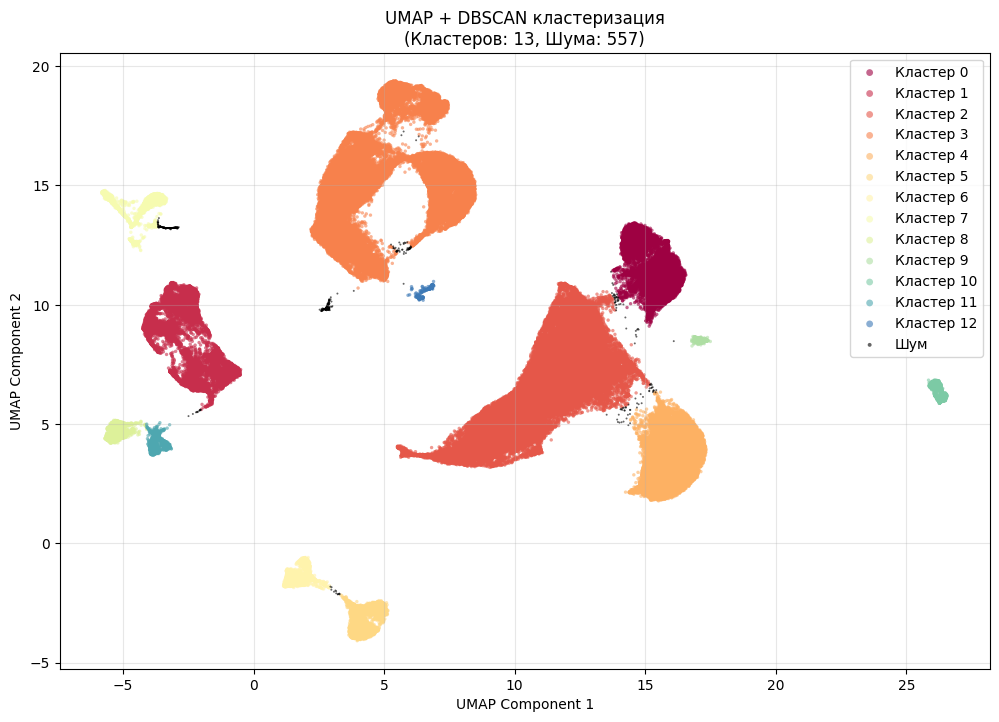

Распределение по кластерам:
Шум: 557 клиентов (0.4%)
Кластер 0: 12476 клиентов (8.9%)
Кластер 1: 14587 клиентов (10.4%)
Кластер 2: 42545 клиентов (30.4%)
Кластер 3: 36264 клиентов (25.9%)
Кластер 4: 17239 клиентов (12.3%)
Кластер 5: 4578 клиентов (3.3%)
Кластер 6: 2746 клиентов (2.0%)
Кластер 7: 3008 клиентов (2.1%)
Кластер 8: 1977 клиентов (1.4%)
Кластер 9: 657 клиентов (0.5%)
Кластер 10: 1255 клиентов (0.9%)
Кластер 11: 1742 клиентов (1.2%)
Кластер 12: 396 клиентов (0.3%)


In [51]:
# DBSCAN
db = DBSCAN(eps=0.5, min_samples=256)
clusters = db.fit_predict(X_umap)

# Анализ результатов
unique_labels = set(clusters)
n_clusters = len(unique_labels) - (1 if -1 in clusters else 0)
n_noise = list(clusters).count(-1)

print(f"Количество найденных кластеров: {n_clusters}")
print(f"Количество шумовых точек (выбросов): {n_noise} ({n_noise/len(clusters)*100:.2f}%)")

# Визуализация
plt.figure(figsize=(12, 8))

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1]
        label = "Шум"
    else:
        label = f"Кластер {k}"

    class_member_mask = (clusters == k)
    xy = X_umap[class_member_mask]
    
    plt.scatter(xy[:, 0], xy[:, 1], 
                c=[col], 
                s=2 if k == -1 else 6,
                alpha=0.6, 
                label=label, 
                edgecolors='none')

plt.title(f'UMAP + DBSCAN кластеризация\n(Кластеров: {n_clusters}, Шума: {n_noise})')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')

if n_clusters < 15:
    plt.legend(loc='best', markerscale=2)
    
plt.grid(True, alpha=0.3)
plt.show()

print("Распределение по кластерам:")
for label in sorted(list(unique_labels)):
    count = list(clusters).count(label)
    name = "Шум" if label == -1 else f"Кластер {label}"
    print(f"{name}: {count} клиентов ({count/len(clusters)*100:.1f}%)")

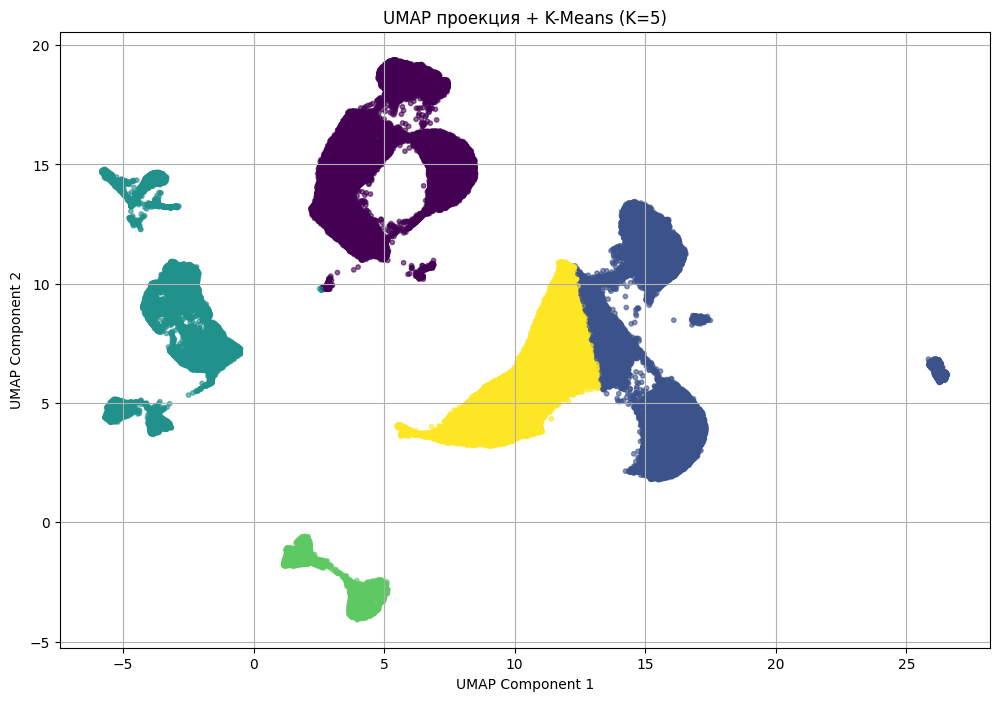

Распределение по кластерам:
Кластер 0: 36893 объектов (26.3%)
Кластер 1: 37832 объектов (27.0%)
Кластер 2: 21536 объектов (15.4%)
Кластер 3: 7336 объектов (5.2%)
Кластер 4: 36430 объектов (26.0%)


In [109]:
# Кластеризация K-Means на полученных проекциях
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters)
clusters = kmeans.fit_predict(X_umap)

# Визуализация
plt.figure(figsize=(12, 8))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=clusters, cmap='viridis', s=10, alpha=0.6)
plt.title(f'UMAP проекция + K-Means (K={n_clusters})')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.grid(True)
plt.show()

# Вывод размеров кластеров
unique, counts = np.unique(clusters, return_counts=True)
print("Распределение по кластерам:")
for u, c in zip(unique, counts):
    print(f"Кластер {u}: {c} объектов ({c/len(clusters)*100:.1f}%)")

# Новые фичи




Для новых фичей будем использовать K-Means, так как он умеет предсказывать кластеры на новых точках напрямую

In [110]:
from scipy.spatial.distance import cdist

X_test_num = X_test_base[num_cols]
X_test_scaled = scaler.transform(X_test_num)
X_test_umap = reducer.transform(X_test_scaled)

# Вычисление расстояний до центроидов для train и test
centroids = kmeans.cluster_centers_

# Матрицы расстояний
dist_train = cdist(X_umap, centroids, metric='euclidean')
dist_test = cdist(X_test_umap, centroids, metric='euclidean')

# Названия для новых колонок расстояний
dist_cols = [f"dist_to_centroid_{i}" for i in range(n_clusters)]

# Создание новых датафреймов
X_train_cluster = X_train_base.copy()
X_test_cluster = X_test_base.copy()

# Добавляем расстояния
for i, col in enumerate(dist_cols):
    X_train_cluster[col] = dist_train[:, i]
    X_test_cluster[col] = dist_test[:, i]

# Добавляем номер кластера
cluster_col_name = "cluster_id"
X_train_cluster[cluster_col_name] = clusters.astype(str)
X_test_cluster[cluster_col_name] = kmeans.predict(X_test_umap).astype(str)

# Формируем обновленные списки колонок
cat_cols_cluster = cat_cols + [cluster_col_name]
num_cols_cluster = num_cols + dist_cols

print(f"Размер X_train_cluster: {X_train_cluster.shape}")
print(f"Размер X_test_cluster: {X_test_cluster.shape}")
print(f"\nНовые категориальные фичи: {[cluster_col_name]}")
print(f"Новые числовые фичи: {dist_cols}")

Размер X_train_cluster: (140027, 38)
Размер X_test_cluster: (60012, 38)

Новые категориальные фичи: ['cluster_id']
Новые числовые фичи: ['dist_to_centroid_0', 'dist_to_centroid_1', 'dist_to_centroid_2', 'dist_to_centroid_3', 'dist_to_centroid_4']


# Обучение и сравнение

In [111]:
# T-learner обычный
t_model = build_t_learner_logreg(num_cols=num_cols, cat_cols=cat_cols)
t_model.fit(X_train_base, y_train, treatment=t_train)
uplift_t = t_model.predict(X_test_base)

# T-learner с фичами кластеризации
t_model_cluster = build_t_learner_logreg(num_cols=num_cols_cluster, cat_cols=cat_cols_cluster)
t_model_cluster.fit(X_train_cluster, y_train, treatment=t_train)
uplift_t_cluster = t_model_cluster.predict(X_test_cluster)

In [112]:
# Сводка uplift-метрик по моделям
metrics = {}

metrics["T-learner_logreg"] = compute_uplift_metrics(
    y_test, uplift_t, t_test
)

metrics["T-learner_logreg_cluster"] = compute_uplift_metrics(
    y_test, uplift_t_cluster, t_test
)

metrics_df = (
    pd.DataFrame(metrics)
    .T
    .rename_axis("model")
    .reset_index()
)

print("Сводная таблица uplift-метрик")
display(metrics_df)

Сводная таблица uplift-метрик


,model,AUUC,Qini,WAU,Uplift@10%,Uplift@20%,Uplift@30%,Uplift@50%
0,T-learner_logreg,0.019362,0.012652,0.033523,0.108821,0.071711,0.057899,0.047868
1,T-learner_logreg_cluster,0.019463,0.012731,0.033196,0.112448,0.079689,0.060144,0.050676


Добавление фичей кластеризации немного увеличило метрики

<Figure size 1200x600 with 0 Axes>

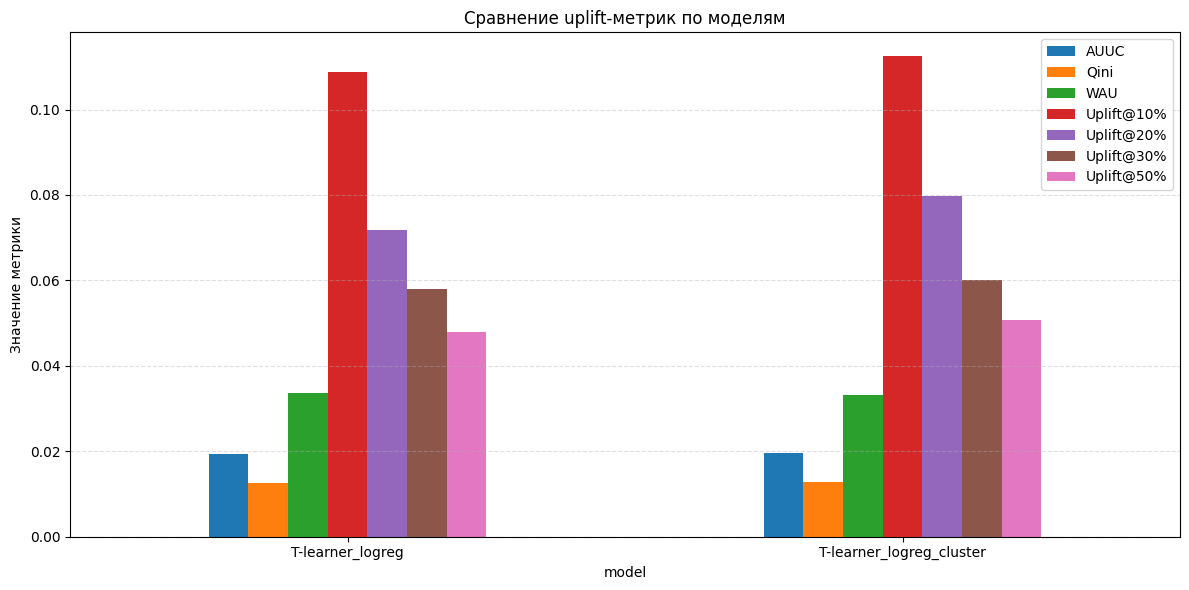

In [113]:
metric_cols = [
    "AUUC",
    "Qini",
    "WAU",
    "Uplift@10%",
    "Uplift@20%",
    "Uplift@30%",
    "Uplift@50%",
]
metrics_for_plot = metrics_df.set_index("model")[metric_cols]

plt.figure(figsize=(12, 6))
metrics_for_plot.plot(kind="bar", figsize=(12, 6))
plt.ylabel("Значение метрики")
plt.title("Сравнение uplift-метрик по моделям")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

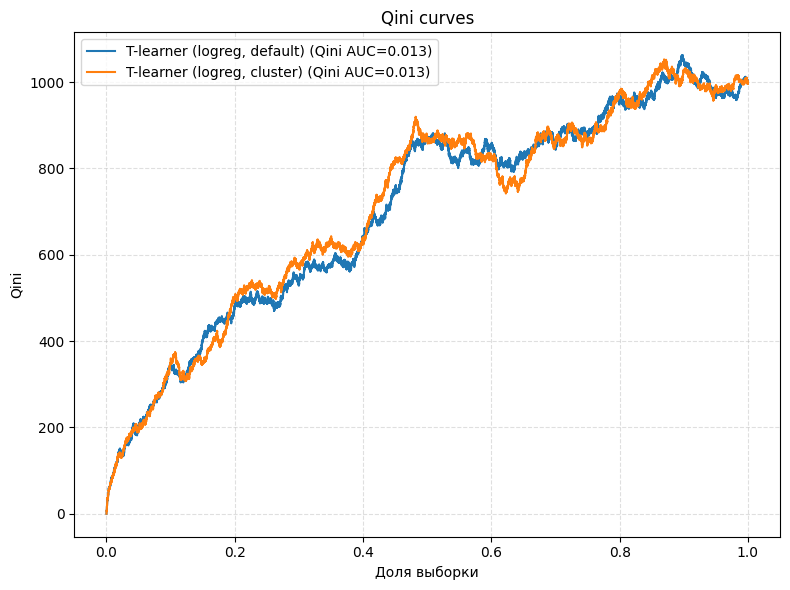

In [114]:
plt.figure(figsize=(8, 6))

plot_qini(y_test, uplift_t, t_test, "T-learner (logreg, default)")
plot_qini(y_test, uplift_t_cluster, t_test, "T-learner (logreg, cluster)")

plt.title("Qini curves")
plt.xlabel("Доля выборки")
plt.ylabel("Qini")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

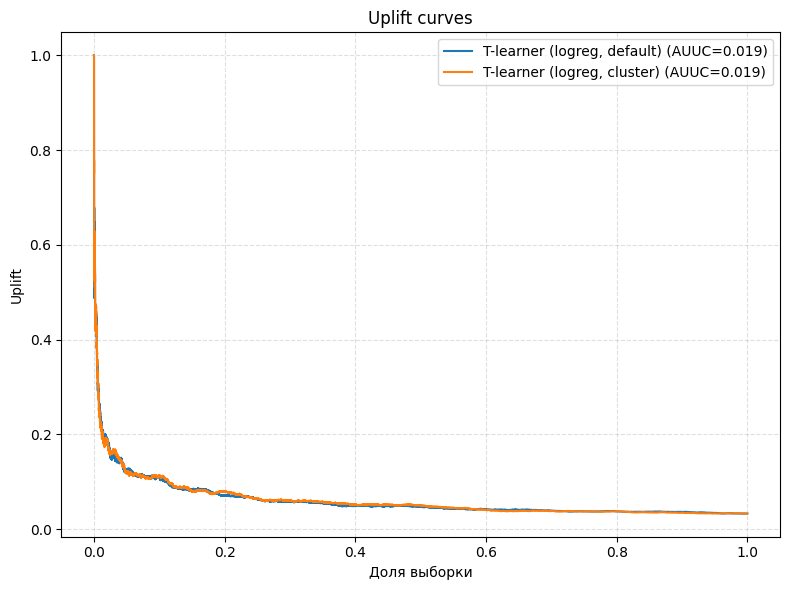

In [115]:
plt.figure(figsize=(8, 6))

plot_uplift(y_test, uplift_t, t_test, "T-learner (logreg, default)")
plot_uplift(y_test, uplift_t_cluster, t_test, "T-learner (logreg, cluster)")

plt.title("Uplift curves")
plt.xlabel("Доля выборки")
plt.ylabel("Uplift")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

In [120]:
t_importance = get_t_logreg_uplift_importance_by_feature(t_model)
t_importance_cluster = get_t_logreg_uplift_importance_by_feature(t_model_cluster)

# соберём полный список фич
all_features = sorted(
    set(t_importance.keys())
    | set(t_importance_cluster.keys())
)

imp_df = pd.DataFrame(
    index=all_features,
    columns=[
        "T_logreg_uplift",
        "T_logreg_uplift_cluster"
    ],
    dtype=float,
)

for f in all_features:
    imp_df.loc[f, "T_logreg_uplift"] = t_importance.get(f, 0.0)
    imp_df.loc[f, "T_logreg_uplift_cluster"] = t_importance_cluster.get(f, 0.0)

# Нормируем по каждой модели
for col in imp_df.columns:
    s = imp_df[col].sum()
    if s > 0:
        imp_df[col] = imp_df[col] / s

imp_df_sorted = imp_df.sort_values("T_logreg_uplift_cluster", ascending=False)

print("Важность признаков (отсортированная по важности в cluster модели)")
display(imp_df_sorted)

Важность признаков (отсортированная по важности в cluster модели)


,T_logreg_uplift,T_logreg_uplift_cluster
log_total_purchase_sum,0.111827,0.096674
cluster_id,0.000000,0.084615
points_spend_ratio,0.099421,0.080675
dist_to_centroid_2,0.000000,0.076067
spend_points_per_transaction,0.089286,0.074362
unique_products_count,0.058330,0.047485
transaction_period_days,0.057110,0.044637
first_issue_year_quarter_idx,0.042309,0.041545
dist_to_centroid_1,0.000000,0.039778
total_express_points_spent,0.047919,0.039599


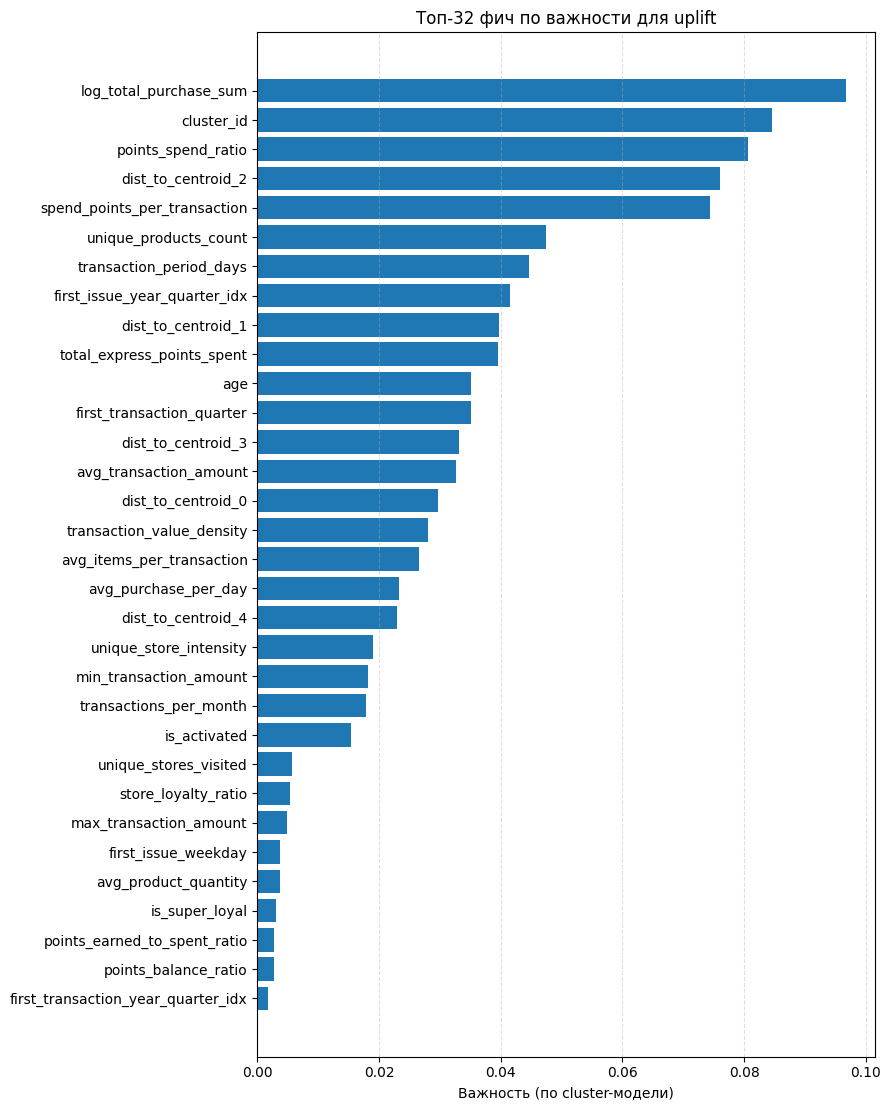

In [123]:
#  График топ-N фич по важности
TOP_N = 32
top_imp = imp_df_sorted.head(TOP_N)

plt.figure(figsize=(9, max(4, TOP_N * 0.35)))
y_pos = np.arange(len(top_imp.index))
plt.barh(y_pos, top_imp["T_logreg_uplift_cluster"].values)
plt.yticks(y_pos, top_imp.index)
plt.gca().invert_yaxis()
plt.xlabel("Важность (по cluster-модели)")
plt.title(f"Топ-{TOP_N} фич по важности для uplift")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


Видно, что новые фичи про кластеры вошли в топ.